# Variational Autoencoders: Learning to Generate with Uncertainty
 
**Dataset:** FashionMNIST (Xiao et al., 2017)  

---

## What this notebook covers

This notebook is a complete tutorial on **Variational Autoencoders (VAEs)**. covered three things:

1. **The reparameterisation trick** — why it exists and how it makes training possible
2. **Latent space visualisation** — what the model actually learns
3. **Reconstruction vs generation quality** — the trade-off at the heart of VAEs


## Step 0 — Install and import dependencies

Run this cell first. These are all the libraries we need.

In [1]:
# Uncomment and run if you need to install:
# install only if needed
!python3 -m pip install torch torchvision matplotlib numpy


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Accessibility: use a colourblind-safe palette throughout ──────────────────
# Wong (2011) 8-colour palette — safe for deuteranopia, protanopia, tritanopia
CB_PALETTE = [
    '#000000', '#E69F00', '#56B4E9', '#009E73',
    '#F0E442', '#0072B2', '#D55E00', '#CC79A7',
    '#999999', '#AA4499'
]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=CB_PALETTE)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Use GPU if available, otherwise CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.3.0


## Step 1 — Load FashionMNIST

We use **FashionMNIST** rather than standard MNIST because:
- Its 10 classes (T-shirt, trouser, pullover, etc.) are more visually diverse
- Making the VAE's learned structure more informative
- Standard MNIST is overused in similar tutorials

Each image is 28×28 pixels, greyscale, normalised to [0, 1].

In [3]:
# FashionMNIST class names for labelling plots later
CLASS_NAMES = [
    'T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

transform = transforms.Compose([
    transforms.ToTensor(),          # converts PIL image to tensor [0,1]
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')
print(f'Image shape      : {train_dataset[0][0].shape}  (C x H x W)')

100%|███████████████████████████████████████████████| 26421880/26421880 [00:01<00:00, 13221907.02it/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████████████████████████████████████████████████| 29515/29515 [00:00<00:00, 1178527.47it/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|█████████████████████████████████████████████████| 4422102/4422102 [00:00<00:00, 18444865.32it/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|████████████████████████████████████████████████████████| 5148/5148 [00:00<00:00, 7430239.85it/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw

Training samples : 60,000
Test samples     : 10,000
Image shape      : torch.Size([1, 28, 28])  (C x H x W)


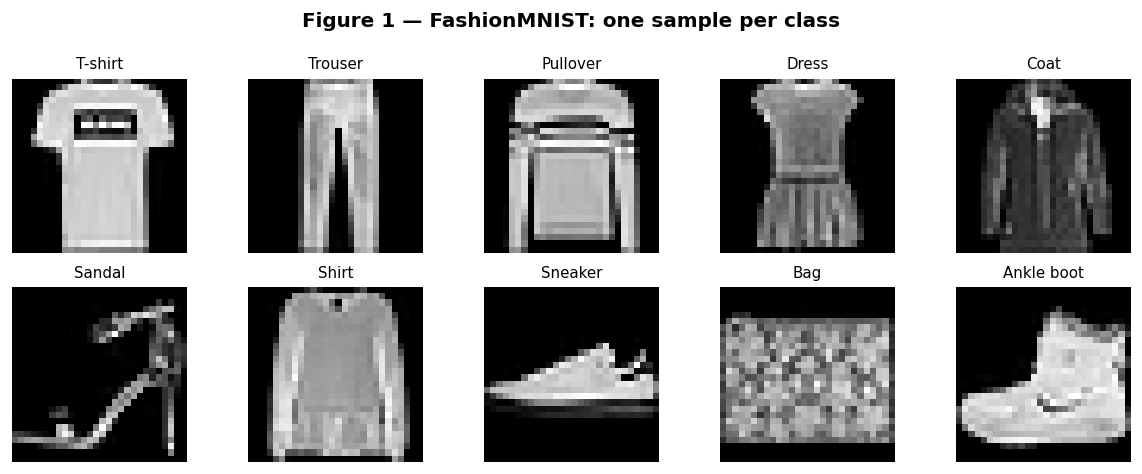

Saved: fig1_fashionmnist_samples.png


In [4]:
# ── Figure 1: Sample images from FashionMNIST ────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Figure 1 — FashionMNIST: one sample per class', fontsize=12, fontweight='bold')

# Pick one sample per class
shown = set()
samples = []
for img, label in train_dataset:
    if label not in shown:
        samples.append((img, label))
        shown.add(label)
    if len(shown) == 10:
        break
samples.sort(key=lambda x: x[1])

for ax, (img, label) in zip(axes.flat, samples):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('fig1_fashionmnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_fashionmnist_samples.png')

## Step 2 — Build the VAE architecture

A VAE has three components:

| Component | Role | Output |
|-----------|------|--------|
| **Encoder** | Compresses an image into a distribution | μ (mean) and log σ² (log-variance) |
| **Reparameterisation** | Samples from that distribution in a differentiable way | z (latent vector) |
| **Decoder** | Reconstructs the image from z | x̂ (reconstructed image) |

### Why do we output log σ² instead of σ²?

Variance must always be positive. By predicting log σ² (which can be any real number) and exponentiating it, we guarantee positivity without needing a `ReLU` or `softplus` constraint. It is numerically more stable too.

In [5]:
class VAE(nn.Module):
    """
    Variational Autoencoder for 28x28 greyscale images.

    Architecture:
        Encoder: 784 -> 512 -> 256 -> (mu, log_var), each of size LATENT_DIM
        Decoder: LATENT_DIM -> 256 -> 512 -> 784

    Args:
        latent_dim (int): Dimensionality of the latent space z.
    """

    def __init__(self, latent_dim: int = 2):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # ── Encoder ──────────────────────────────────────────────────────────
        # Takes a flattened 784-dim image and produces mu and log_var.
        self.encoder_shared = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu      = nn.Linear(256, latent_dim)   # mean of q(z|x)
        self.fc_log_var = nn.Linear(256, latent_dim)   # log-variance of q(z|x)

        # ── Decoder ──────────────────────────────────────────────────────────
        # Takes a latent vector z and reconstructs the 784-dim image.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid(),   # outputs are probabilities in [0,1] — matches pixel range
        )

    def encode(self, x):
        """Pass x through the shared encoder layers, return mu and log_var."""
        x = x.view(-1, 784)          # flatten 28x28 -> 784
        h = self.encoder_shared(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    def reparameterise(self, mu, log_var):
        """
        The reparameterisation trick (Kingma & Welling, 2013).

        Instead of sampling z ~ N(mu, sigma^2) directly (which blocks gradients),
        we write:   z = mu + sigma * epsilon,   epsilon ~ N(0, I)

        This moves the randomness into epsilon (a fixed distribution with no
        learnable parameters), so gradients can flow through mu and sigma.

        sigma = exp(0.5 * log_var)   [ensures sigma > 0]
        """
        if self.training:
            # Only sample during training; at test time use the mean (deterministic)
            std = torch.exp(0.5 * log_var)          # sigma
            eps = torch.randn_like(std)              # epsilon ~ N(0,I)
            return mu + std * eps
        else:
            return mu

    def decode(self, z):
        """Decode latent vector z back to image space."""
        return self.decoder(z)

    def forward(self, x):
        """Full forward pass: encode -> reparameterise -> decode."""
        mu, log_var = self.encode(x)
        z           = self.reparameterise(mu, log_var)
        x_recon     = self.decode(z)
        return x_recon, mu, log_var


# Instantiate with 2D latent space so we can visualise it as a 2D scatter plot
LATENT_DIM = 2
model = VAE(latent_dim=LATENT_DIM).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'VAE architecture:\n{model}')
print(f'\nTotal trainable parameters: {total_params:,}')

VAE architecture:
VAE(
  (encoder_shared): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=2, bias=True)
  (fc_log_var): Linear(in_features=256, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Total trainable parameters: 1,068,820


## Step 3 — Define the ELBO loss function

VAEs are trained to maximise the **Evidence Lower BOund (ELBO)**. In practice we *minimise* the negative ELBO, which has two terms:

$$\mathcal{L} = \underbrace{\text{BCE}(x, \hat{x})}_{\text{Reconstruction loss}} + \beta \cdot \underbrace{D_{KL}\bigl(q(z|x) \,\|\, p(z)\bigr)}_{\text{KL divergence}}$$

| Term | What it does | Analogy |
|------|-------------|--------|
| **Reconstruction loss** | Forces the decoder to accurately rebuild the input | "Remember what you saw" |
| **KL divergence** | Forces the latent distribution to stay close to N(0,I) | "Don't spread out too far" |

The **KL divergence** between two Gaussians has a closed-form solution:
$$D_{KL} = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

The `beta` parameter (set to 1 here, giving standard VAE) controls the trade-off. Higher beta = more disentangled latent space but blurrier reconstructions (β-VAE, Higgins et al., 2017).

In [6]:
def vae_loss(x_recon, x_orig, mu, log_var, beta=1.0):
    """
    Negative ELBO loss = Reconstruction loss + beta * KL divergence.

    Args:
        x_recon  : reconstructed image from decoder, shape (B, 784)
        x_orig   : original image, shape (B, 1, 28, 28)
        mu       : encoder mean, shape (B, latent_dim)
        log_var  : encoder log-variance, shape (B, latent_dim)
        beta     : weight on the KL term (1.0 = standard VAE)

    Returns:
        total    : scalar loss
        recon    : reconstruction loss component (for logging)
        kl       : KL divergence component (for logging)
    """
    # Flatten original images to match x_recon shape
    x_flat = x_orig.view(-1, 784)

    # Binary cross-entropy: treats each pixel as an independent Bernoulli
    # reduction='sum' then divide by batch size gives per-sample average
    recon = F.binary_cross_entropy(x_recon, x_flat, reduction='sum') / x_orig.size(0)

    # Closed-form KL divergence between N(mu, sigma^2) and N(0, I)
    # See Appendix B of Kingma & Welling (2013)
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x_orig.size(0)

    total = recon + beta * kl
    return total, recon.item(), kl.item()

print("Done")

Done


## Step 4 — Train the VAE

We train for 30 epochs with the Adam optimiser (learning rate 1e-3), which is standard for VAEs. We track both loss components separately so we can plot them afterwards.

In [7]:
EPOCHS = 30
LEARNING_RATE = 1e-3

optimiser = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Store losses per epoch for plotting
history = {
    'train_total': [], 'train_recon': [], 'train_kl': [],
    'test_total' : [], 'test_recon' : [], 'test_kl' : [],
}


def run_epoch(loader, train=True):
    """Run one full epoch. Returns mean total, recon, and KL losses."""
    model.train(train)      # sets dropout/batchnorm behaviour (and our reparameterise flag)
    totals = [0.0, 0.0, 0.0]
    with torch.set_grad_enabled(train):
        for x, _ in loader:          # we don't use class labels during training
            x = x.to(DEVICE)
            x_recon, mu, log_var = model(x)
            loss, recon, kl = vae_loss(x_recon, x, mu, log_var)

            if train:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()

            totals[0] += loss.item()
            totals[1] += recon
            totals[2] += kl

    n = len(loader)
    return totals[0]/n, totals[1]/n, totals[2]/n


print(f'Training VAE for {EPOCHS} epochs on {DEVICE}...')
print(f'{"Epoch":>6} | {"Train loss":>12} | {"Recon":>8} | {"KL":>8} | {"Test loss":>12}')
print('-' * 60)

for epoch in range(1, EPOCHS + 1):
    tr_total, tr_recon, tr_kl = run_epoch(train_loader, train=True)
    te_total, te_recon, te_kl = run_epoch(test_loader,  train=False)

    for k, v in zip(history.keys(), [tr_total, tr_recon, tr_kl, te_total, te_recon, te_kl]):
        history[k].append(v)

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6} | {tr_total:>12.2f} | {tr_recon:>8.2f} | {tr_kl:>8.2f} | {te_total:>12.2f}')

print('\nTraining complete!')

# Save model weights
torch.save(model.state_dict(), 'vae_fashionmnist.pt')
print('Model saved to vae_fashionmnist.pt')

Training VAE for 30 epochs on cpu...
 Epoch |   Train loss |    Recon |       KL |    Test loss
------------------------------------------------------------
     1 |       290.35 |   284.00 |     6.35 |       270.33
     5 |       260.83 |   254.48 |     6.35 |       260.14
    10 |       257.90 |   251.44 |     6.46 |       258.09
    15 |       255.99 |   249.39 |     6.59 |       256.60
    20 |       254.75 |   248.08 |     6.67 |       255.04
    25 |       254.17 |   247.43 |     6.74 |       255.21
    30 |       254.71 |   247.96 |     6.75 |       255.75

Training complete!
Model saved to vae_fashionmnist.pt


## Step 5 — Figure 2: Training curves

Plotting the reconstruction and KL loss separately reveals the tension between the two objectives. Early in training the reconstruction loss dominates; as the KL term rises, the model learns a smoother, more regularised latent space.

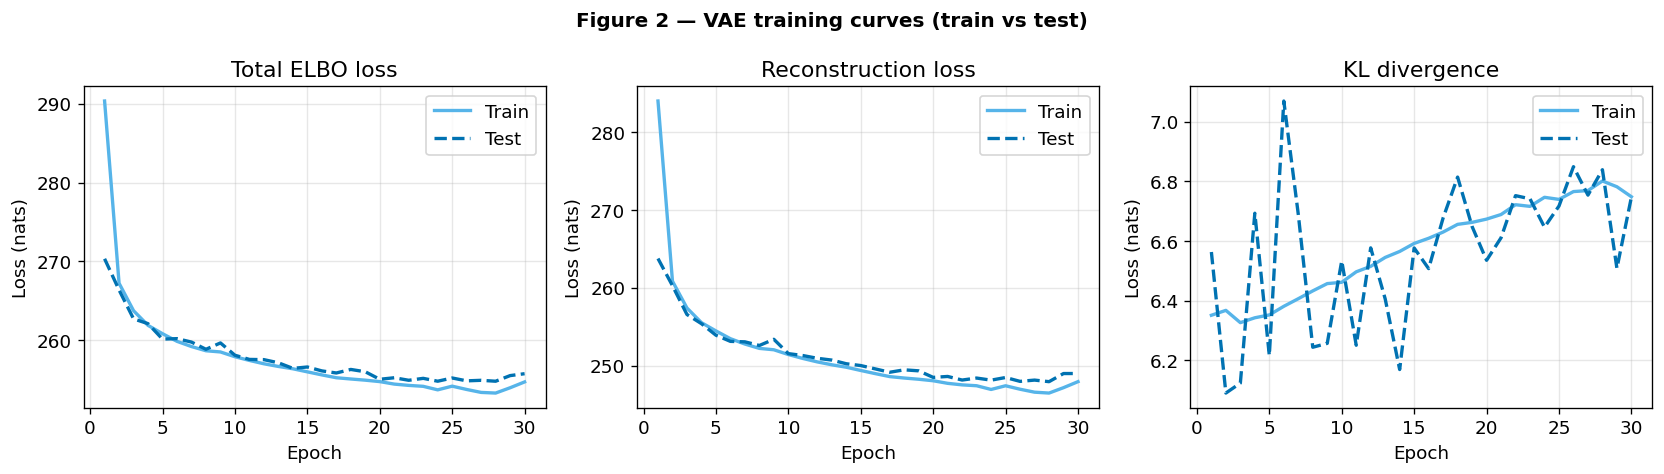

Saved: fig2_training_curves.png


In [8]:
# ── Figure 2: Training curves ─────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Figure 2 — VAE training curves (train vs test)', fontsize=12, fontweight='bold')

panels = [
    ('Total ELBO loss',       'train_total', 'test_total'),
    ('Reconstruction loss',   'train_recon', 'test_recon'),
    ('KL divergence',         'train_kl',    'test_kl'),
]

for ax, (title, tr_key, te_key) in zip(axes, panels):
    ax.plot(epochs_range, history[tr_key], label='Train', color=CB_PALETTE[2], linewidth=2)
    ax.plot(epochs_range, history[te_key], label='Test',  color=CB_PALETTE[5],
            linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (nats)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_training_curves.png')

## Step 6 — Figure 3: Latent space visualisation

Because we chose `latent_dim=2`, we can plot every test image as a single point in 2D space, coloured by its true class label. A well-trained VAE should show **clusters** (similar items nearby) with **smooth boundaries** (no sharp gaps between clusters, unlike a standard autoencoder).

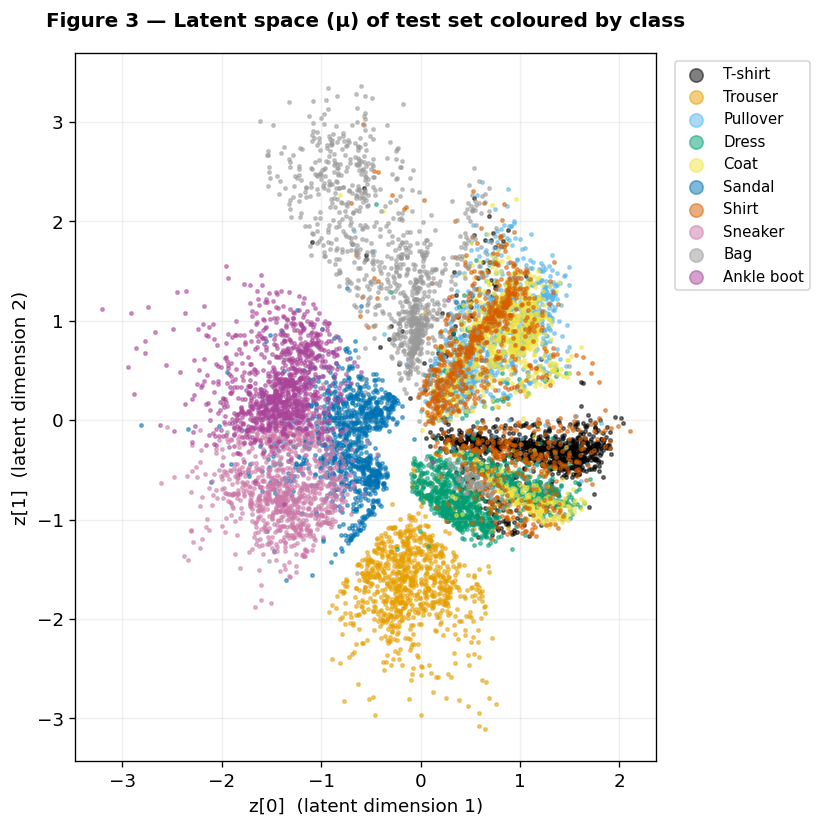

Saved: fig3_latent_space.png


In [9]:
# Encode the entire test set
model.eval()
all_mu, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        mu, _ = model.encode(x.to(DEVICE))
        all_mu.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_mu     = np.concatenate(all_mu,     axis=0)   # shape (10000, 2)
all_labels = np.concatenate(all_labels, axis=0)   # shape (10000,)

# ── Figure 3: 2D latent space scatter plot ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle('Figure 3 — Latent space (μ) of test set coloured by class',
             fontsize=12, fontweight='bold')

for class_id in range(10):
    mask = all_labels == class_id
    ax.scatter(
        all_mu[mask, 0], all_mu[mask, 1],
        s=4, alpha=0.5,
        color=CB_PALETTE[class_id],
        label=CLASS_NAMES[class_id],
        rasterized=True   # keeps file size small
    )

ax.set_xlabel('z[0]  (latent dimension 1)')
ax.set_ylabel('z[1]  (latent dimension 2)')
ax.legend(markerscale=4, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('fig3_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_latent_space.png')

## Step 7 — Figure 4: Reconstruction quality

We pass 10 test images through the full VAE (encode → reparameterise → decode) and compare the original with the reconstruction. Blurriness is expected — it is a direct consequence of the reconstruction loss averaging over multiple plausible images.

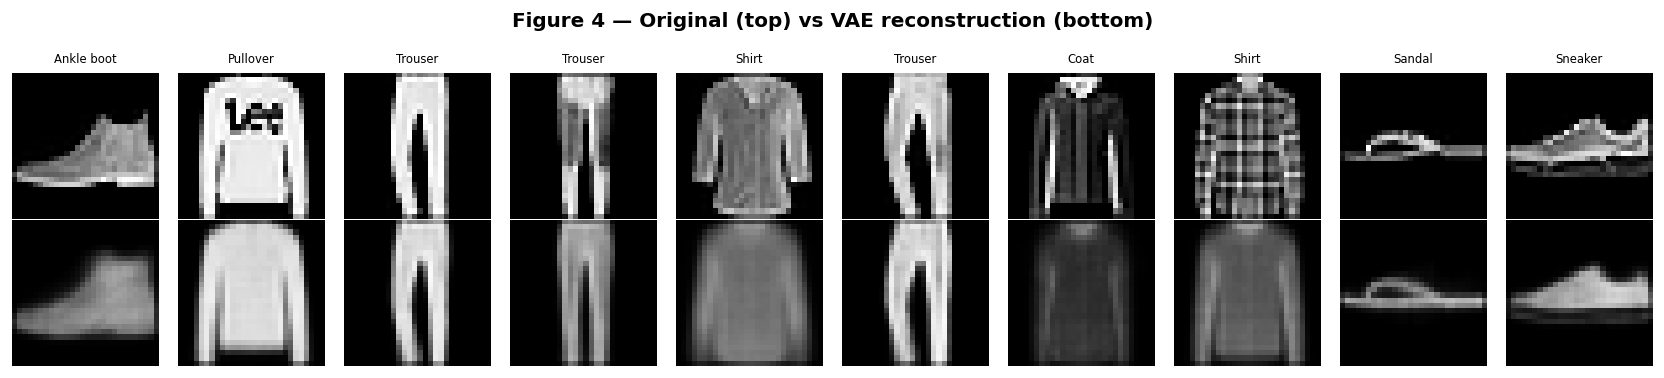

Saved: fig4_reconstructions.png


In [10]:
# Grab one batch from the test set
model.eval()
test_imgs, test_lbls = next(iter(test_loader))
test_imgs = test_imgs[:10].to(DEVICE)   # take first 10

with torch.no_grad():
    recons, _, _ = model(test_imgs)

# Reshape reconstructions from 784 -> 28x28
recons    = recons.cpu().view(-1, 28, 28).numpy()
originals = test_imgs.cpu().squeeze().numpy()

# ── Figure 4: Originals vs reconstructions ────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
fig.suptitle('Figure 4 — Original (top) vs VAE reconstruction (bottom)',
             fontsize=12, fontweight='bold')

for i in range(10):
    axes[0, i].imshow(originals[i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(CLASS_NAMES[test_lbls[i].item()], fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(recons[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Reconstructed', fontsize=9)

plt.tight_layout()
plt.savefig('fig4_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_reconstructions.png')

## Step 8 — Figure 5: Latent space traversal (generation)

The key advantage of a VAE over a standard autoencoder is that the latent space is **continuous and regularised** — we can sample *any* point in it and the decoder will produce a meaningful image. Here we create a grid of evenly spaced points across the latent space and decode each one.

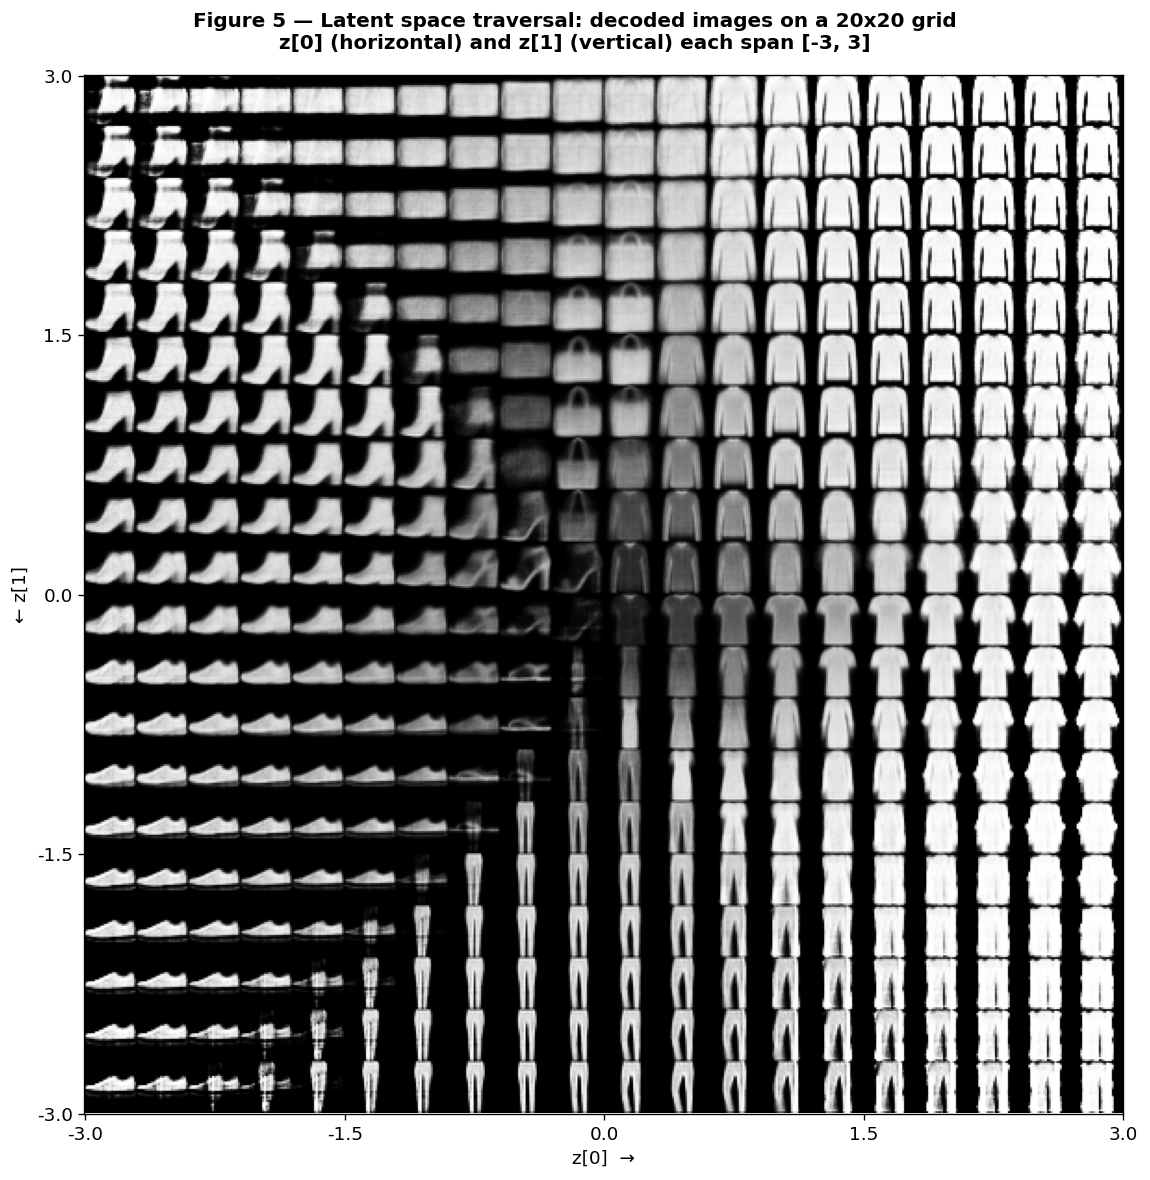

Saved: fig5_latent_traversal.png


In [11]:
# ── Figure 5: Latent space traversal grid ────────────────────────────────────
# Create a 20x20 grid of latent points evenly spaced between -3 and 3
# (most of the N(0,1) prior mass lies in [-3, 3])
GRID_SIZE = 20
RANGE     = 3.0

grid_x = np.linspace(-RANGE, RANGE, GRID_SIZE)
grid_y = np.linspace( RANGE, -RANGE, GRID_SIZE)   # y reversed so top = high z[1]

canvas = np.zeros((28 * GRID_SIZE, 28 * GRID_SIZE))

model.eval()
with torch.no_grad():
    for row_i, yi in enumerate(grid_y):
        for col_i, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(DEVICE)
            img = model.decode(z).cpu().view(28, 28).numpy()
            canvas[
                row_i * 28 : (row_i + 1) * 28,
                col_i * 28 : (col_i + 1) * 28
            ] = img

fig, ax = plt.subplots(figsize=(10, 10))
fig.suptitle(
    'Figure 5 — Latent space traversal: decoded images on a 20x20 grid\n'
    'z[0] (horizontal) and z[1] (vertical) each span [-3, 3]',
    fontsize=12, fontweight='bold'
)
ax.imshow(canvas, cmap='gray', vmin=0, vmax=1)
ax.set_xlabel('z[0]  →', fontsize=11)
ax.set_ylabel('← z[1]', fontsize=11)
ax.set_xticks(np.linspace(0, 28*GRID_SIZE, 5))
ax.set_xticklabels([f'{v:.1f}' for v in np.linspace(-RANGE, RANGE, 5)])
ax.set_yticks(np.linspace(0, 28*GRID_SIZE, 5))
ax.set_yticklabels([f'{v:.1f}' for v in np.linspace(RANGE, -RANGE, 5)])

plt.tight_layout()
plt.savefig('fig5_latent_traversal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_latent_traversal.png')

## Step 9 — Bonus: Latent interpolation between two classes

We encode two real images from different classes and linearly interpolate between their latent codes. A smooth transition confirms the latent space is well-structured. A standard autoencoder would produce garbage midpoints.

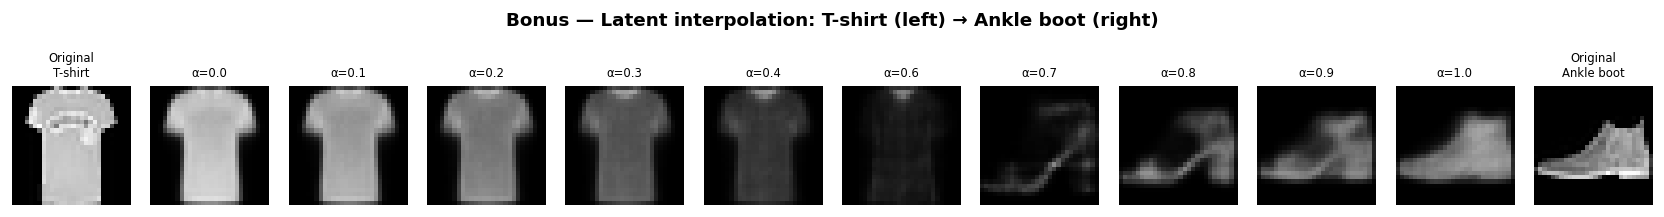

Saved: fig_bonus_interpolation.png


In [12]:
# Find one example of class 0 (T-shirt) and class 9 (Ankle boot)
def get_sample(dataset, target_class):
    for img, label in dataset:
        if label == target_class:
            return img.unsqueeze(0)   # add batch dimension

img_a = get_sample(test_dataset, 0).to(DEVICE)   # T-shirt
img_b = get_sample(test_dataset, 9).to(DEVICE)   # Ankle boot

model.eval()
with torch.no_grad():
    mu_a, _ = model.encode(img_a)
    mu_b, _ = model.encode(img_b)

    N_STEPS = 10
    alphas  = np.linspace(0, 1, N_STEPS)
    interps = []
    for alpha in alphas:
        z_interp  = (1 - alpha) * mu_a + alpha * mu_b
        img_interp = model.decode(z_interp).cpu().view(28, 28).numpy()
        interps.append(img_interp)

# ── Bonus Figure: Interpolation ───────────────────────────────────────────────
fig, axes = plt.subplots(1, N_STEPS + 2, figsize=(14, 2))
fig.suptitle('Bonus — Latent interpolation: T-shirt (left) → Ankle boot (right)',
             fontsize=11, fontweight='bold')

axes[0].imshow(img_a.cpu().squeeze(), cmap='gray')
axes[0].set_title('Original\nT-shirt', fontsize=7)
axes[0].axis('off')

for i, img in enumerate(interps):
    axes[i + 1].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[i + 1].set_title(f'α={alphas[i]:.1f}', fontsize=7)
    axes[i + 1].axis('off')

axes[-1].imshow(img_b.cpu().squeeze(), cmap='gray')
axes[-1].set_title('Original\nAnkle boot', fontsize=7)
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('fig_bonus_interpolation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_bonus_interpolation.png')

## Step 10 — Key takeaways

| Concept | What we demonstrated |
|---------|---------------------|
| **Reparameterisation trick** | Enables gradients to flow through the sampling step by separating randomness (ε) from learnable parameters (μ, σ) |
| **ELBO loss** | Reconstruction loss + KL divergence creates the tension that makes the latent space structured and continuous |
| **Latent space** | Classes cluster naturally without any class labels during training (unsupervised!) |
| **Generation** | Any point sampled from N(0,1) decodes to a plausible garment — impossible with a standard autoencoder |
| **Interpolation** | Smooth morphing between classes confirms the latent space is continuous and well-behaved |
